In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/GOOG.csv")  # your file

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())

                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2004-08-19  2.490664  2.591785  2.390042  2.499133   2.499133  897427216
2004-08-20  2.515820  2.716817  2.503118  2.697639   2.697639  458857488
2004-08-23  2.758411  2.826406  2.716070  2.724787   2.724787  366857939
2004-08-24  2.770615  2.779581  2.579581  2.611960   2.611960  306396159
2004-08-25  2.614201  2.689918  2.587302  2.640104   2.640104  184645512


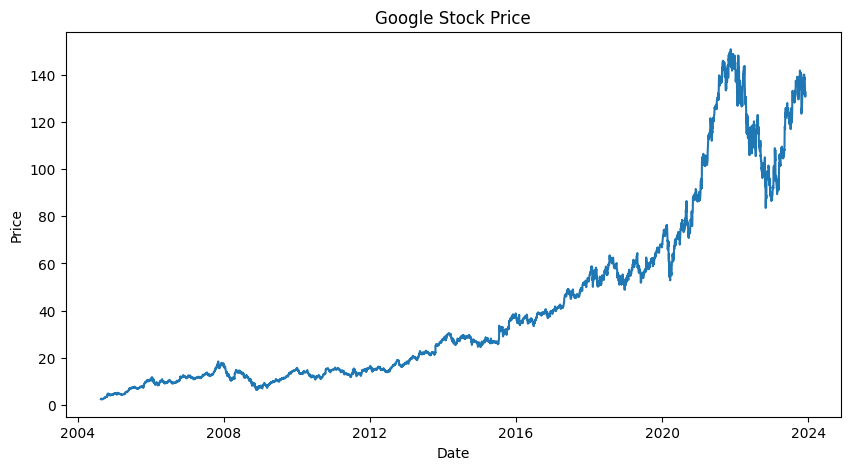

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Google Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [4]:
data = df[['Close']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [5]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [6]:
TIME_STEPS = 60

train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size - TIME_STEPS:]

X_train, y_train = create_sequences(train_data, TIME_STEPS)
X_test, y_test = create_sequences(test_data, TIME_STEPS)

# reshape for RNN
X_train = X_train.reshape((X_train.shape[0], TIME_STEPS, 1))
X_test = X_test.reshape((X_test.shape[0], TIME_STEPS, 1))

In [7]:
model = models.Sequential([
    layers.Input(shape=(TIME_STEPS, 1)),

    layers.SimpleRNN(64, return_sequences=True),
    layers.Dropout(0.2),

    layers.SimpleRNN(64),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

In [8]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0062 - mae: 0.0477 - val_loss: 0.0031 - val_mae: 0.0530
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 9.9785e-04 - mae: 0.0214 - val_loss: 0.0011 - val_mae: 0.0299
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 5.7300e-04 - mae: 0.0163 - val_loss: 0.0011 - val_mae: 0.0300
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 5.1713e-04 - mae: 0.0148 - val_loss: 0.0025 - val_mae: 0.0472
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 3.3785e-04 - mae: 0.0125 - val_loss: 1.6878e-04 - val_mae: 0.0105
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 3.1820e-04 - mae: 0.0118 - val_loss: 0.0010 - val_mae: 0.0291
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 2.8518e-04 - mae: 0.0111 - val_loss: 9.1213e-04 - val_mae: 0.0272
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.3949e-04 - mae: 0.0102 - val_loss: 0.0012 - val_mae: 0.0331
Epoch 9/50
1

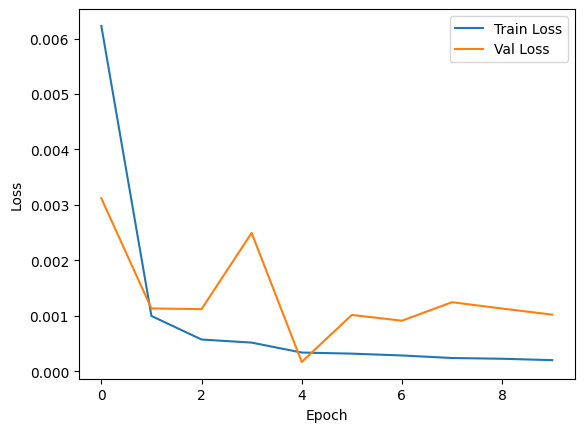

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1,1))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [12]:
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 335.7585074818963
RMSE: 18.323714347312237
MAE: 15.515077235829795


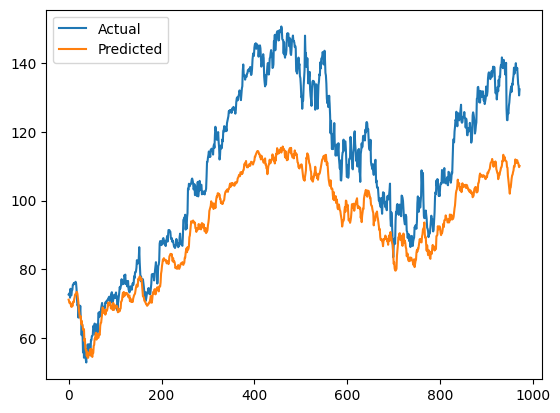

In [13]:
plt.plot(y_actual, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()
plt.show()

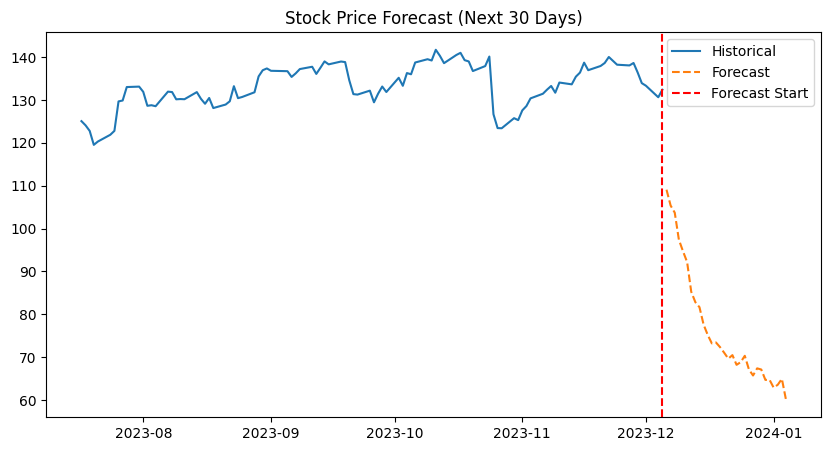

In [14]:
#Step 1: Take Last 60 Days
last_sequence = data_scaled[-TIME_STEPS:]
future_input = last_sequence.reshape(1, TIME_STEPS, 1)

#Step 2: Predict Future Values
future_predictions = []

n_future = 30   # predict next 30 days

for _ in range(n_future):
    pred = model.predict(future_input, verbose=0)

    future_predictions.append(pred[0, 0])

    # Slide window
    future_input = np.append(
        future_input[:, 1:, :],
        pred.reshape(1, 1, 1),
        axis=1
    )

#Step 3: Convert Back to Original Price
future_prices = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

#Step 4: Create Future Dates
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=n_future
)

#Step 5: Plot Forecast (VERY IMPORTANT)
plt.figure(figsize=(10,5))

# Last 100 days of real data
plt.plot(df.index[-100:], df['Close'][-100:], label='Historical')

# Future prediction
plt.plot(future_dates, future_prices, label='Forecast', linestyle='--')

plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')

plt.legend()
plt.title("Stock Price Forecast (Next 30 Days)")
plt.show()